In [2]:
# Cell 1: Import necessary libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB7
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose
from tensorflow.keras.layers import concatenate, BatchNormalization, Activation, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import MeanIoU
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence

2025-03-31 18:53:43.297981: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-31 18:53:43.529058: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743427423.616352  383778 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743427423.640373  383778 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743427423.821515  383778 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
# Cell 2: Define constants and paths
IMAGE_DIR = "../data/MSFD/1/face_crop"
MASK_DIR = "../data/MSFD/1/face_crop_segmentation"
IMG_SIZE = (128, 128)
IMG_HEIGHT, IMG_WIDTH = 128, 128
BATCH_SIZE = 8
EPOCHS = 50
CHECKPOINT_PATH = "./checkpoints/unet_efficientb7.h5"
MODEL_PATH = "./models/unet_efficientb7_final.h5"

In [ ]:
# 3: Data loading function
def load_data(image_dir, mask_dir, img_size=(IMG_HEIGHT, IMG_WIDTH), limit=2000):
    images, masks = [], []
    image_files = sorted(os.listdir(image_dir))  # Ensure correct order
    mask_files = sorted(os.listdir(mask_dir))
    print(f"Found {len(image_files)} images and {len(mask_files)} masks")
    seen=0
    for img_file, mask_file in zip(image_files, mask_files):
        if seen >= limit:
            break
        seen += 1

        # Read and resize images
        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)
        
        if not os.path.exists(img_path) or not os.path.exists(mask_path):
            continue
            
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Could not read image {img_path}")
            continue
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        img = cv2.resize(img, img_size) / 255.0  # Normalize
        
        # Read and resize masks
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print(f"Warning: Could not read mask {mask_path}")
            continue
            
        mask = cv2.resize(mask, img_size)
        mask = np.expand_dims(mask, axis=-1)  # Add channel dimension
        mask = mask / 255.0  # Convert to binary (0 or 1)
        mask = (mask > 0.5).astype(np.float32)  # Ensure binary values
        
        images.append(img)
        masks.append(mask)
    
    return np.array(images), np.array(masks)

In [ ]:
# 4: Data Generator class for loading batches
class DataGenerator(Sequence):
    def __init__(self, X, y, batch_size=BATCH_SIZE, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.X))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        X_batch = self.X[batch_indexes]
        y_batch = self.y[batch_indexes]
        return X_batch, y_batch
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [ ]:
# 5: Load and split the dataset
X, Y = load_data(IMAGE_DIR, MASK_DIR,limit=3000)
print(f"Dataset loaded: {X.shape}, {Y.shape}")

# Split data into training and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

Found 9383 images and 9383 masks
Dataset loaded: (2000, 128, 128, 3), (2000, 128, 128, 1)


In [8]:
print(f"Training set: {X_train.shape}, {Y_train.shape}")
print(f"Validation set: {X_val.shape}, {Y_val.shape}")

# Create data generators
train_gen = DataGenerator(X_train, Y_train, batch_size=BATCH_SIZE)
val_gen = DataGenerator(X_val, Y_val, batch_size=BATCH_SIZE)

Training set: (1600, 128, 128, 3), (1600, 128, 128, 1)
Validation set: (400, 128, 128, 3), (400, 128, 128, 1)


In [9]:
# Cell 6: Define metrics - Dice coefficient and IoU
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def iou_coef(y_true, y_pred, smooth=1):
    intersection = tf.keras.backend.sum(tf.keras.backend.abs(y_true * y_pred), axis=[1, 2, 3])
    union = tf.keras.backend.sum(y_true, axis=[1, 2, 3]) + tf.keras.backend.sum(y_pred, axis=[1, 2, 3]) - intersection
    return tf.keras.backend.mean((intersection + smooth) / (union + smooth))

In [ ]:
# 7 (Replace): Define the U-Net with EfficientNetB7 backbone
def build_unet_efficientb7(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    # Input tensor
    inputs = Input(input_shape)
    
    # EfficientNetB7 backbone (without top layer)
    efficientnet = EfficientNetB7(include_top=False, weights='imagenet', input_tensor=inputs)
    
    # Extract features from different levels of EfficientNetB7
    # These layer names are specific to EfficientNetB7 architecture
    s1 = efficientnet.get_layer('block1a_project_bn').output  # 64x64
    s2 = efficientnet.get_layer('block2g_add').output        # 32x32
    s3 = efficientnet.get_layer('block3g_add').output        # 16x16
    s4 = efficientnet.get_layer('block5g_add').output        # 8x8
    s5 = efficientnet.get_layer('block7c_add').output        # 4x4
    
    # Decoder path
    # Bridge
    b1 = Conv2D(512, (3, 3), padding='same')(s5)
    b1 = BatchNormalization()(b1)
    b1 = Activation('relu')(b1)
    b1 = Dropout(0.3)(b1)
    b1 = Conv2D(512, (3, 3), padding='same')(b1)
    b1 = BatchNormalization()(b1)
    b1 = Activation('relu')(b1)
    
    # Decoder 1
    d1 = Conv2DTranspose(256, (3, 3), strides=(2, 2), padding='same')(b1)  # 8x8
    d1 = concatenate([d1, s4])
    d1 = Conv2D(256, (3, 3), padding='same')(d1)
    d1 = BatchNormalization()(d1)
    d1 = Activation('relu')(d1)
    d1 = Dropout(0.3)(d1)
    d1 = Conv2D(256, (3, 3), padding='same')(d1)
    d1 = BatchNormalization()(d1)
    d1 = Activation('relu')(d1)
    
    # Decoder 2
    d2 = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(d1)  # 16x16
    d2 = concatenate([d2, s3])
    d2 = Conv2D(128, (3, 3), padding='same')(d2)
    d2 = BatchNormalization()(d2)
    d2 = Activation('relu')(d2)
    d2 = Dropout(0.3)(d2)
    d2 = Conv2D(128, (3, 3), padding='same')(d2)
    d2 = BatchNormalization()(d2)
    d2 = Activation('relu')(d2)
    
    # Decoder 3
    d3 = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(d2)  # 32x32
    d3 = concatenate([d3, s2])
    d3 = Conv2D(64, (3, 3), padding='same')(d3)
    d3 = BatchNormalization()(d3)
    d3 = Activation('relu')(d3)
    d3 = Dropout(0.3)(d3)
    d3 = Conv2D(64, (3, 3), padding='same')(d3)
    d3 = BatchNormalization()(d3)
    d3 = Activation('relu')(d3)
    
    # Decoder 4
    d4 = Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same')(d3)  # 64x64
    d4 = concatenate([d4, s1])
    d4 = Conv2D(32, (3, 3), padding='same')(d4)
    d4 = BatchNormalization()(d4)
    d4 = Activation('relu')(d4)
    d4 = Dropout(0.3)(d4)
    d4 = Conv2D(32, (3, 3), padding='same')(d4)
    d4 = BatchNormalization()(d4)
    d4 = Activation('relu')(d4)
    
    # Final upsampling to original size
    outputs = Conv2DTranspose(16, (3, 3), strides=(2, 2), padding='same')(d4)  # 128x128
    outputs = Conv2D(16, (3, 3), padding='same')(outputs)
    outputs = BatchNormalization()(outputs)
    outputs = Activation('relu')(outputs)
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(outputs)
    
    # Create model
    model = Model(inputs=[inputs], outputs=[outputs])
    
    return model

In [ ]:
# 8: Build and compile model
model = build_unet_efficientb7(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Compile model with custom metrics
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coef, iou_coef, 'binary_accuracy']
)

# Display model summary
model.summary()

I0000 00:00:1743427493.051914  383778 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6292 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 128, 128,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 128, 128,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 129, 129,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │      1,728 │ stem_conv_pad[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 64, 64,    │        576 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 64, 64,    │        256 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 64, 64,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 64)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 64)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 16)  │      1,040 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 64)  │      1,088 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 64, 64,    │          0 │ block1a_activati… │
│ (Multiply)          │ 64)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │      2,048 │ block1a_se_excit

 Total params: 65,337,608 (249.24 MB)

 Trainable params: 65,044,641 (248.13 MB)

 Non-trainable params: 292,967 (1.12 MB)

In [ ]:
#  9: Set up callbacks for training
# Create checkpoint directory if it doesn't exist
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

callbacks = [
    ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor='val_dice_coef',
        verbose=1,
        save_best_only=True,
        mode='max'
    ),
    EarlyStopping(
        monitor='val_dice_coef',
        patience=10,
        verbose=1,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_dice_coef',
        factor=0.1,
        patience=5,
        verbose=1,
        mode='max',
        min_lr=1e-7
    )
]

In [ ]:
#  10: Train the model
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

# Save the final model
model.save(MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Epoch 1/50


/home/nira/miniconda3/envs/unet/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/home/nira/miniconda3/envs/unet/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)
I0000 00:00:1743427575.333258  388179 service.cc:152] XLA service 0x75c8b0002200 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1743427575.333286  388179 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-03-31 18:56:18.06944

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - binary_accuracy: 0.6009 - dice_coef: 0.5392 - iou_coef: 0.3735 - loss: 0.4608
Epoch 1: val_dice_coef improved from -inf to 0.72552, saving model to ./checkpoints/unet_efficientb7.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 170s 160ms/step - binary_accuracy: 0.6016 - dice_coef: 0.5396 - iou_coef: 0.3740 - loss: 0.4604 - val_binary_accuracy: 0.8425 - val_dice_coef: 0.7255 - val_iou_coef: 0.5680 - val_loss: 0.2745 - learning_rate: 1.0000e-04
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - binary_accuracy: 0.8793 - dice_coef: 0.7418 - iou_coef: 0.5874 - loss: 0.2582
Epoch 2: val_dice_coef improved from 0.72552 to 0.74479, saving model to ./checkpoints/unet_efficientb7.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 122ms/step - binary_accuracy: 0.8793 - dice_coef: 0.7418 - iou_coef: 0.5874 - loss: 0.2582 - val_binary_accuracy: 0.8620 - val_dice_coef: 0.7448 - val_iou_coef: 0.5921 - val_loss: 0.2552 - learning_rate: 1.0000e-04
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - binary_accuracy: 0.8927 - dice_coef: 0.7677 - iou_coef: 0.6188 - loss: 0.2323
Epoch 3: val_dice_coef improved from 0.74479 to 0.76840, saving model to ./checkpoints/unet_efficientb7.h5


...

200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - binary_accuracy: 0.9797 - dice_coef: 0.9686 - iou_coef: 0.9358 - loss: 0.0314 - val_binary_accuracy: 0.9006 - val_dice_coef: 0.8506 - val_iou_coef: 0.7499 - val_loss: 0.1494 - learning_rate: 1.0000e-05
Epoch 39/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - binary_accuracy: 0.9811 - dice_coef: 0.9709 - iou_coef: 0.9407 - loss: 0.0291
Epoch 39: val_dice_coef did not improve from 0.85057
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - binary_accuracy: 0.9811 - dice_coef: 0.9709 - iou_coef: 0.9407 - loss: 0.0291 - val_binary_accuracy: 0.9006 - val_dice_coef: 0.8503 - val_iou_coef: 0.7490 - val_loss: 0.1497 - learning_rate: 1.0000e-05
Epoch 40/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - binary_accuracy: 0.9813 - dice_coef: 0.9712 - iou_coef: 0.9410 - loss: 0.0288
Epoch 40: val_dice_coef did not improve from 0.85057
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - binary_accuracy: 0.9813 - dice_coef: 0.9712 - iou_coef: 0.9410 - loss: 0.0288 - va

200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 120ms/step - binary_accuracy: 0.9818 - dice_coef: 0.9716 - iou_coef: 0.9417 - loss: 0.0284 - val_binary_accuracy: 0.9007 - val_dice_coef: 0.8509 - val_iou_coef: 0.7495 - val_loss: 0.1491 - learning_rate: 1.0000e-05
Epoch 42/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - binary_accuracy: 0.9821 - dice_coef: 0.9723 - iou_coef: 0.9421 - loss: 0.0277
Epoch 42: val_dice_coef did not improve from 0.85094
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - binary_accuracy: 0.9821 - dice_coef: 0.9723 - iou_coef: 0.9421 - loss: 0.0277 - val_binary_accuracy: 0.9005 - val_dice_coef: 0.8501 - val_iou_coef: 0.7500 - val_loss: 0.1499 - learning_rate: 1.0000e-05
Epoch 43/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - binary_accuracy: 0.9824 - dice_coef: 0.9729 - iou_coef: 0.9448 - loss: 0.0271
Epoch 43: val_dice_coef improved from 0.85094 to 0.85110, saving model to ./checkpoints/unet_efficientb7.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - binary_accuracy: 0.9824 - dice_coef: 0.9729 - iou_coef: 0.9448 - loss: 0.0271 - val_binary_accuracy: 0.9004 - val_dice_coef: 0.8511 - val_iou_coef: 0.7506 - val_loss: 0.1489 - learning_rate: 1.0000e-05
Epoch 44/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - binary_accuracy: 0.9828 - dice_coef: 0.9731 - iou_coef: 0.9436 - loss: 0.0269
Epoch 44: val_dice_coef did not improve from 0.85110
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - binary_accuracy: 0.9828 - dice_coef: 0.9731 - iou_coef: 0.9436 - loss: 0.0269 - val_binary_accuracy: 0.9003 - val_dice_coef: 0.8505 - val_iou_coef: 0.7494 - val_loss: 0.1495 - learning_rate: 1.0000e-05
Epoch 45/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - binary_accuracy: 0.9825 - dice_coef: 0.9729 - iou_coef: 0.9449 - loss: 0.0271
Epoch 45: val_dice_coef did not improve from 0.85110
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - binary_accuracy: 0.9825 - dice_coef: 0.9729 - iou_coef: 0.9449 - loss: 0.0271 - va

200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 119ms/step - binary_accuracy: 0.9829 - dice_coef: 0.9733 - iou_coef: 0.9456 - loss: 0.0267 - val_binary_accuracy: 0.9003 - val_dice_coef: 0.8511 - val_iou_coef: 0.7498 - val_loss: 0.1489 - learning_rate: 1.0000e-05
Epoch 47/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - binary_accuracy: 0.9833 - dice_coef: 0.9740 - iou_coef: 0.9472 - loss: 0.0260
Epoch 47: val_dice_coef did not improve from 0.85113
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - binary_accuracy: 0.9833 - dice_coef: 0.9740 - iou_coef: 0.9472 - loss: 0.0260 - val_binary_accuracy: 0.9000 - val_dice_coef: 0.8504 - val_iou_coef: 0.7494 - val_loss: 0.1496 - learning_rate: 1.0000e-05
Epoch 48/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - binary_accuracy: 0.9830 - dice_coef: 0.9738 - iou_coef: 0.9450 - loss: 0.0262
Epoch 48: val_dice_coef did not improve from 0.85113

Epoch 48: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-07.
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - bina

Model saved to ./models/unet_efficientb7_final.h5


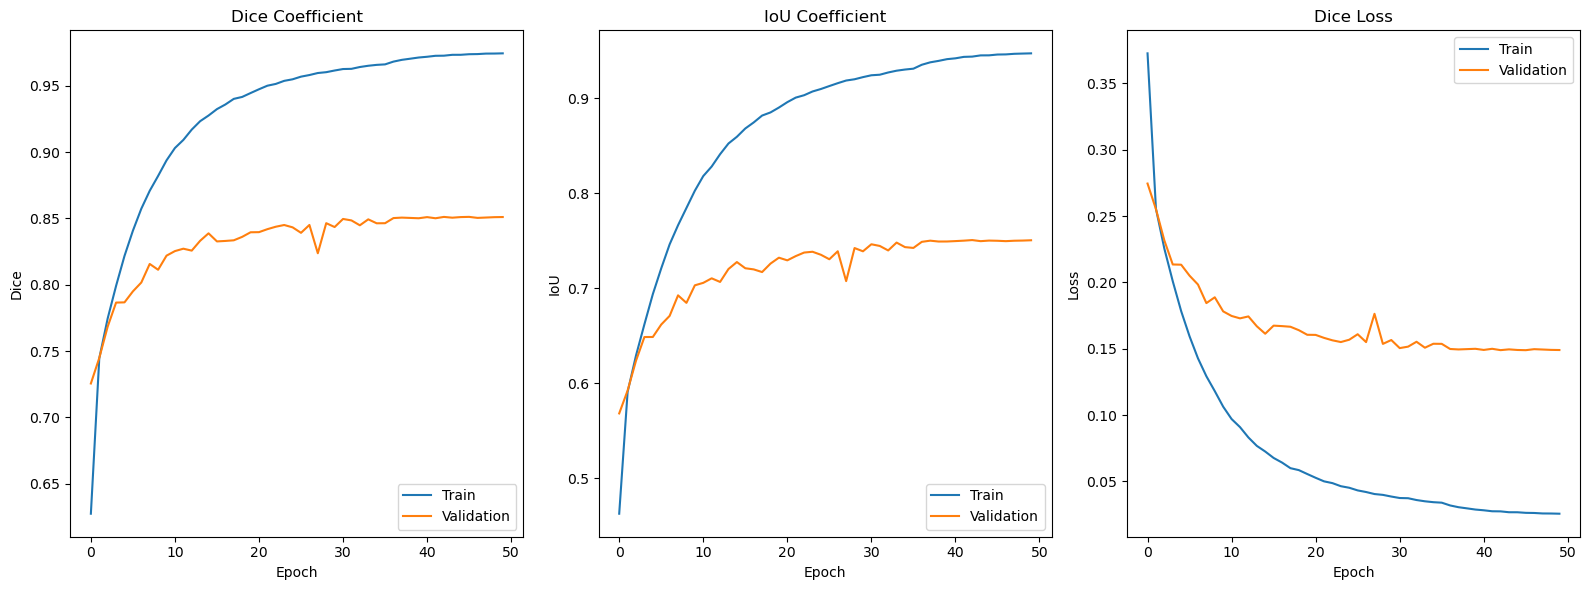

In [ ]:
#  11: Plot training history
plt.figure(figsize=(16, 6))

# Plot Dice coefficient
plt.subplot(1, 3, 1)
plt.plot(history.history['dice_coef'])
plt.plot(history.history['val_dice_coef'])
plt.title('Dice Coefficient')
plt.ylabel('Dice')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

# Plot IoU
plt.subplot(1, 3, 2)
plt.plot(history.history['iou_coef'])
plt.plot(history.history['val_iou_coef'])
plt.title('IoU Coefficient')
plt.ylabel('IoU')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

# Plot Loss
plt.subplot(1, 3, 3)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Dice Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
#  12: Evaluate the model on validation set
# Load the best model
best_model = tf.keras.models.load_model(CHECKPOINT_PATH, custom_objects={
    'dice_loss': dice_loss,
    'dice_coef': dice_coef,
    'iou_coef': iou_coef
})

# Evaluate on validation set
val_results = best_model.evaluate(val_gen)
print(f'Validation Dice Loss: {val_results[0]:.4f}')
print(f'Validation Dice Coef: {val_results[1]:.4f}')
print(f'Validation IoU: {val_results[2]:.4f}')
print(f'Validation Accuracy: {val_results[3]:.4f}')

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - binary_accuracy: 0.9012 - dice_coef: 0.8515 - iou_coef: 0.7500 - loss: 0.1485
Validation Dice Loss: 0.1494
Validation Dice Coef: 0.8506
Validation IoU: 0.7498
Validation Accuracy: 0.9003


In [ ]:
#  13: Create a function to visualize segmentation results
def visualize_prediction(model, img_idx, images=X_val, masks=Y_val):
    # Get sample image and mask
    img = images[img_idx]
    true_mask = masks[img_idx]
    
    # Predict mask
    pred_mask = model.predict(np.expand_dims(img, axis=0))[0]
    
    # Convert to binary
    pred_mask_binary = (pred_mask > 0.5).astype(np.uint8)
    
    # Calculate metrics
    dice = dice_coef(true_mask, pred_mask_binary).numpy()
    iou = iou_coef(true_mask, pred_mask_binary).numpy()
    
    # Visualize
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(img)
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    
    ax[1].imshow(true_mask[:,:,0], cmap='gray')
    ax[1].set_title('True Mask')
    ax[1].axis('off')
    
    ax[2].imshow(pred_mask[:,:,0], cmap='gray')
    ax[2].set_title(f'Predicted Mask\nDice: {dice:.4f}, IoU: {iou:.4f}')
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return dice, iou

# Visualize a few examples
for i in range(5):  # Show 5 random examples
    idx = np.random.randint(0, len(X_val))
    print(f"Sample {i+1}, Image Index: {idx}")
    visualize_prediction(best_model, idx)

Sample 1, Image Index: 341
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


InvalidArgumentError: cannot compute Mul as input #1(zero-based) was expected to be a float tensor but is a uint8 tensor [Op:Mul] name: 

In [ ]:
# 14: Inference - Function for making predictions on new images
def predict_mask(model, image_path, threshold=0.5):
    # Read and preprocess the image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT)) / 255.0
    
    # Predict mask
    pred_mask = model.predict(np.expand_dims(img_resized, axis=0))[0]
    pred_mask_binary = (pred_mask > threshold).astype(np.uint8) * 255
    
    # Resize mask back to original image size
    original_h, original_w = img.shape[:2]
    pred_mask_original_size = cv2.resize(pred_mask_binary, (original_w, original_h))
    
    # Visualize
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(img)
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    
    ax[1].imshow(img_resized)
    ax[1].set_title('Resized Image (Model Input)')
    ax[1].axis('off')
    
    ax[2].imshow(pred_mask[:,:,0], cmap='gray')
    ax[2].set_title('Predicted Mask')
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return pred_mask_original_size

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


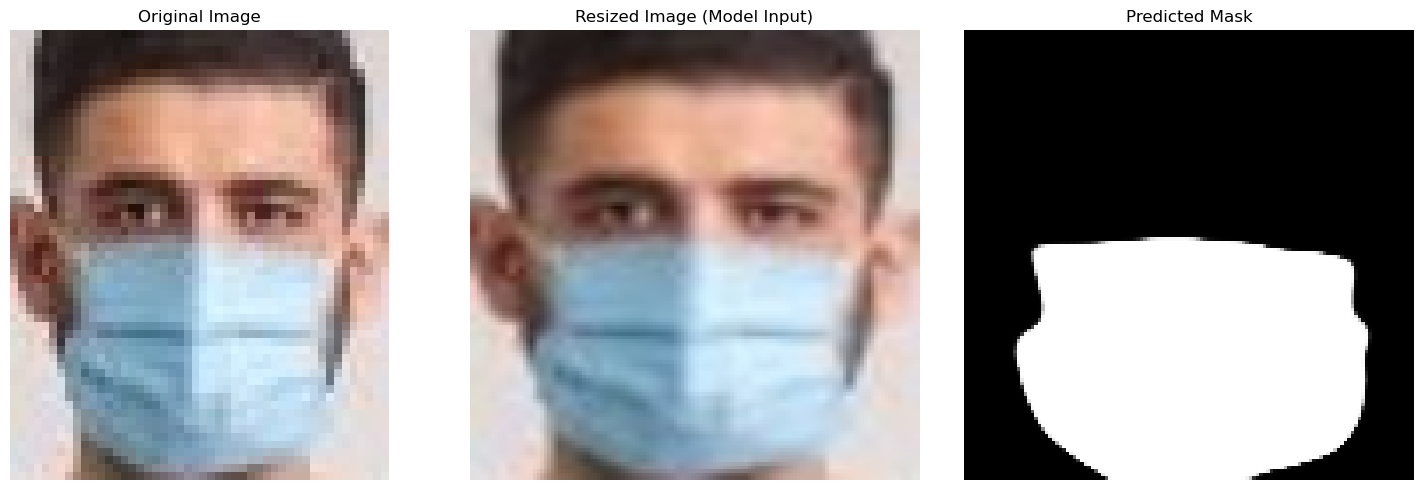

Prediction saved to predicted_mask.png


In [ ]:
# 15: Run inference on a new image

# Path to a new image we want to test
new_image_path = "../data/MSFD/1/face_crop/000001_1.jpg"  

try:
    # Check if file exists
    if os.path.exists(new_image_path):
        # Run inference
        predicted_mask = predict_mask(best_model, new_image_path)
        
        # Save the predicted mask
        output_path = "predicted_mask.png"
        cv2.imwrite(output_path, predicted_mask)
        print(f"Prediction saved to {output_path}")
    else:
        print(f"Image not found at {new_image_path}")
        print("You can use any image from your dataset or a new image by changing the 'new_image_path' variable.")
        
        # Alternatively, use a random image from the validation set for demo
        rand_idx = np.random.randint(0, len(X_val))
        print(f"Using a random image from validation set (index: {rand_idx})")
        visualize_prediction(best_model, rand_idx)
except Exception as e:
    print(f"Error during inference: {e}")

In [ ]:
# 16: Calculate metrics on the entire validation set
def calculate_metrics_on_dataset(model, images, masks, batch_size=BATCH_SIZE):
    dice_scores = []
    iou_scores = []
    
    # Process in batches to avoid memory issues
    num_samples = len(images)
    num_batches = int(np.ceil(num_samples / batch_size))
    
    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, num_samples)
        
        batch_images = images[start_idx:end_idx]
        batch_masks = masks[start_idx:end_idx]
        
        # Predict masks
        pred_masks = model.predict(batch_images)
        pred_masks_binary = (pred_masks > 0.5).astype(np.float32)
        
        # Calculate metrics for each image
        for j in range(len(batch_images)):
            true_mask = batch_masks[j]
            pred_mask = pred_masks_binary[j]
            
            # Calculate Dice
            dice = dice_coef(true_mask, pred_mask).numpy()
            dice_scores.append(dice)
            
            # Calculate IoU
            iou = iou_coef(true_mask, pred_mask).numpy()
            iou_scores.append(iou)
    
    # Calculate average metrics
    avg_dice = np.mean(dice_scores)
    avg_iou = np.mean(iou_scores)
    
    return avg_dice, avg_iou, dice_scores, iou_scores

# Calculate metrics on validation set
avg_dice, avg_iou, all_dice_scores, all_iou_scores = calculate_metrics_on_dataset(best_model, X_val, Y_val)

print(f"Average Dice Coefficient: {avg_dice:.4f}")
print(f"Average IoU: {avg_iou:.4f}")

# Plot distribution of scores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(all_dice_scores, bins=20, alpha=0.7)
plt.axvline(avg_dice, color='r', linestyle='--', label=f'Mean: {avg_dice:.4f}')
plt.title('Distribution of Dice Coefficients')
plt.xlabel('Dice Coefficient')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(all_iou_scores, bins=20, alpha=0.7)
plt.axvline(avg_iou, color='r', linestyle='--', label=f'Mean: {avg_iou:.4f}')
plt.title('Distribution of IoU Scores')
plt.xlabel('IoU Score')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()